# `01-intro.ipynb`
- Langgraph는 "흐름제어"가 핵심
- 모든 노드가 공유하는 State

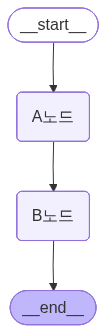

In [3]:
# Tiny Graph
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# 1. State 정의 (각 노드마다 사용할 데이터들 집합 -> 메세지 히스토리도 포함)
# {'text": "abcd"}
class MyState(TypedDict):
    text: str

# 2. Node 만든다
def node_a(state: MyState):
    print(state['text'])
    new_text = state['text'] + ' -> A노드 통과'
    return {'text': new_text}

def node_b(state: MyState):
    print(state['text'])
    new_text = state['text'] + ' -> B노드 통과'
    return {'text': new_text}

# 3. Edge 연결한다
graph = StateGraph(MyState) # 새로운 상태그래프. MyState를 모두 공유하기

graph.add_node('A노드', node_a) # 새로운 노드 등록. 앞은 부를 이름, 뒤는 함수 이름
graph.add_node('B노드', node_b)

graph.add_edge(START, 'A노드') # 앞과 뒤를 잇는다. # = graph.set_entry_point('A노드')
graph.add_edge('A노드', 'B노드') # 앞과 뒤를 잇는다.
graph.add_edge('B노드', END) # 앞과 뒤를 잇는다. # = graph.set_finish_point('A노드')

# 4. 그래프를 만든다 (compile)
app = graph.compile()
app

In [4]:
app.invoke({'text': '아주 작은 그래프'})

아주 작은 그래프
아주 작은 그래프 -> A노드 통과


{'text': '아주 작은 그래프 -> A노드 통과 -> B노드 통과'}

## 조건 라우터

In [5]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

# State 정의
# {'message': 'blah blah', 'is_ok': True, 'next_step': '계속 진행'}
class SystemState(TypedDict):
    message: str
    is_ok: bool
    next_step: str


In [ ]:
# app.invoke({'message': '문제없음'})

# Node 만들기
def process_message(state: SystemState):
    print('---메세지처리---', state)
    msg = state['message']
    if ('error' in msg.lower()) or ('에러' in msg):
        result = False
    else:
        result = True
    return {'is_ok': result} # node에서 젠체 state를 return할 필요 없음. 바뀐것만 return 하면 state의 나머지 부분은 그냥 넘어감

# {'message': '문제없음', 'is_ok': True}
def normal_node(state: SystemState):
    print('---문제없음노드---', state)

    return {
        'message': state['message'],
        'is_ok': state['is_ok'],
        'next_step': '문제 없음. 계속 진행'
    } # 여기도 바뀌는 부분만 return해도 괜찮음

# {'message': '문제없음', 'is_ok': False}
def error_node(state: SystemState):
    print('---에러발생노드---', state)

    return {
        'message': state['message'],
        'is_ok': state['is_ok'],
        'next_step': '에러 발생. 삐용삐용!'
    }

In [16]:
process_message({'message': '에러가 발생했습니다.'})

---메세지처리--- {'message': '에러가 발생했습니다.'}


{'is_ok': False}

In [17]:
# 라우터 (노드 아님)
def router(state: SystemState):
    if state['is_ok'] == True:
        return '괜춘'
    else:
        return '안괜춘'

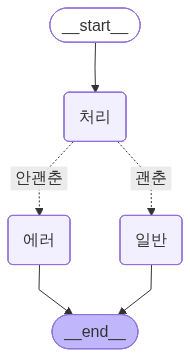

In [18]:
# 합치기
graph = StateGraph(SystemState)

graph.add_node('처리', process_message)
graph.add_node('일반', normal_node)
graph.add_node('에러', error_node)

graph.add_edge(START, '처리')
graph.add_conditional_edges(
    '처리', # 분기 시작 지점
    router,
    {
        '괜춘': '일반', # router 함수의 결과 -> 다음 노드 이름
        '안괜춘': '에러'
    }
)
graph.add_edge('일반', END)
graph.add_edge('에러', END)

app = graph.compile()
app

In [19]:
app.invoke({'message': 'very good'})

---메세지처리--- {'message': 'very good'}
---문제없음ㄴ노드--- {'message': 'very good', 'is_ok': True}


{'message': 'very good', 'is_ok': True, 'next_step': '문제 없음. 계속 진행'}